In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import json

Matplotlib is building the font cache; this may take a moment.


In [2]:
df = pd.read_csv('kidney_disease.csv')
print(df.shape)
df.head()

(400, 26)


,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


In [3]:
cols = ['age', 'bp', 'bgr', 'htn', 'classification']
data = df[cols].copy()

# Xóa khoảng trắng
for col in ['htn', 'classification']:
    data[col] = data[col].astype(str).str.strip()

# Ép số
for col in ['age', 'bp', 'bgr']:
    data[col] = pd.to_numeric(data[col], errors='coerce')

# Map
data['htn'] = data['htn'].map({'yes': 1, 'no': 0})
data['classification'] = data['classification'].map({'ckd': 1, 'notckd': 0})

print(data.isnull().sum())

age                9
bp                12
bgr               44
htn                2
classification     0
dtype: int64


In [4]:
data['age'] = data['age'].fillna(data['age'].median())
data['bp']  = data['bp'].fillna(data['bp'].median())
data['bgr'] = data['bgr'].fillna(data['bgr'].median())
data['htn'] = data['htn'].fillna(data['htn'].mode()[0])
data = data.dropna(subset=['classification'])

print(data.isnull().sum())

age               0
bp                0
bgr               0
htn               0
classification    0
dtype: int64


In [5]:
X = data[['age', 'bp', 'bgr', 'htn']]
y = data['classification']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [7]:
y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1       :", f1_score(y_test, y_pred))
print("AUC      :", roc_auc_score(y_test, y_proba))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy : 0.7625
Precision: 0.8444444444444444
Recall   : 0.76
F1       : 0.8
AUC      : 0.876
Confusion matrix:
 [[23  7]
 [12 38]]


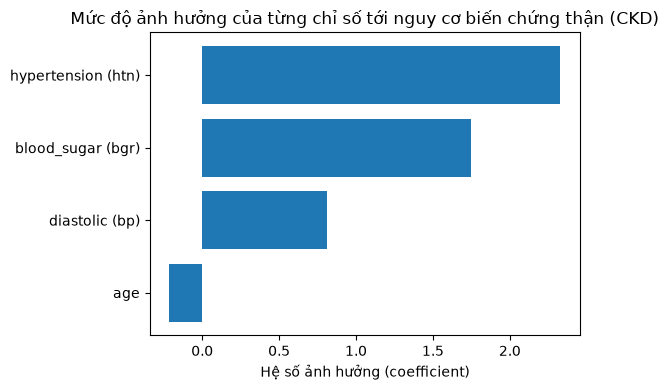

In [8]:
plt.figure(figsize=(6,4))
plt.barh(['age', 'diastolic (bp)', 'blood_sugar (bgr)', 'hypertension (htn)'], model.coef_[0])
plt.xlabel("Hệ số ảnh hưởng (coefficient)")
plt.title("Mức độ ảnh hưởng của từng chỉ số tới nguy cơ biến chứng thận (CKD)")
plt.tight_layout()
plt.savefig("feature_importance.png")
plt.show()

In [9]:
export = {
    "features": ["age", "diastolic", "blood_sugar", "hypertension"],
    "scaler_mean": scaler.mean_.tolist(),
    "scaler_scale": scaler.scale_.tolist(),
    "coefficients": model.coef_[0].tolist(),
    "intercept": float(model.intercept_[0])
}

with open("ckd-risk-model.json", "w") as f:
    json.dump(export, f, indent=2)

print(json.dumps(export, indent=2))

{
  "features": [
    "age",
    "diastolic",
    "blood_sugar",
    "hypertension"
  ],
  "scaler_mean": [
    51.184375,
    76.875,
    142.196875,
    0.365625
  ],
  "scaler_scale": [
    16.925029715169632,
    13.927827361078252,
    71.50862266352482,
    0.48160498271404956
  ],
  "coefficients": [
    -0.2140997252153488,
    0.8084795549937347,
    1.750194247172042,
    2.3289733038083296
  ],
  "intercept": 2.047137190638535
}


In [10]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def predict_manual(age, bp, bgr, htn):
    x = np.array([age, bp, bgr, htn])
    x_scaled = (x - scaler.mean_) / scaler.scale_
    z = model.intercept_[0] + np.dot(model.coef_[0], x_scaled)
    return sigmoid(z) * 100

sample = X_test.iloc[0]
print("Manual :", predict_manual(sample['age'], sample['bp'], sample['bgr'], sample['htn']))
print("Sklearn:", model.predict_proba(scaler.transform([sample.values]))[0][1] * 100)

Manual : 14.618951366943852
Sklearn: 14.61895136694385


c:\Users\admin\GlucoTrackingAlert\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
